In [340]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate, PauliEvolutionGate, HamiltonianGate, SwapGate, CXGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker
#from qiskit.circuit.library.generalized_gates import RXXGate, RYYGate, RZZGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RGate, ZGate, MCXGate, CXGate, ECRGate, CU3Gate
from qiskit.circuit import Gate
from scipy.linalg import expm
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeFez
from qiskit_ibm_runtime import SamplerV2 as Sampler
#from tqdm import tqdm
import time
from qiskit.quantum_info import Operator
from qiskit.providers import JobStatus
from qiskit_aer import Aer
import qiskit as qk

In [341]:
from qiskit.quantum_info import Operator, Pauli
from qiskit.quantum_info.operators import SparsePauliOp
from scipy.linalg import expm
from scipy.linalg import svd
from scipy.constants import physical_constants
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.synthesis import TwoQubitBasisDecomposer
from tqdm import tqdm
import mthree

In [342]:
import qiskit_aer as aer
from helpers import generate_noise_scaled_circuit, extrapolate_to_zero, count_2q

import sys
sys.path.append('../utils/')
sys.path.append('../circuits/')

from JobResult import JobResult
from DecoherenceRenormalizer import DecoherenceRenormalizer as DR

In [ ]:
# --------------------- Simulator options --------------------
simulator_flag = True
noiseless_flag = False
linear_noiseless_flag = False # use linear connectivity from IBM Sherbrooke, but noiseless
reduced_noise_flag = False # use a custom noise model with reduced noise compared to IBM Sherbrooke
method = 'statevector'

fakebackend = FakeSherbrooke()

config = None
target = None

PLAN = 3 # @FIXME: only plan 3 for run and get result is implemented

# --------------------- Error Mitigation Flags --------------------

APPROXIMATION_DEGREE = 0.995

MIN_DEPTH_INTERACT = True
SUZUKI_TROTTER_FLAG = False
DYNAMIC_SUZUKI_FLAG = False

DYNAMIC_DECOUPLING_FLAG = False
PAULI_TWIRLING_FLAG = False
pt_rands = 16
pt_shots = 128
ZERO_NOISE_EXTRAP_FLAG = False
zne_noise_factors = (1, 3, 5)
zne_extrapolator = 'exponential'

M3FLAG = True
mit = None

PHS_FLAG = True

DR_FLAG = True

# --------------------- Saving options --------------------

save_postfix = "4nu_0_20_DR_approx995"

save_prob_name = '4nu_0_20_DR_approx995'

SAVEFIG_FLAG = False

# --------------------- Initialization of backend --------------------
backend = None

if simulator_flag:
    # Using simulator
    if linear_noiseless_flag:
        # Noiseless simulator with linear connectivity (of IBM Sherbrooke)
        print("Using linear noiseless simulator")
        config = fakebackend.configuration()
        coupling_map = config.coupling_map
        simulator = AerSimulator(method=method, coupling_map=coupling_map, noise_model=None)
        backend = simulator
        target = simulator.target
    else:
        # Other simulator options
        if not noiseless_flag:
            # Simulator with noise
            if not reduced_noise_flag:
                print("Using fake IBM simulator")
                # noise model from sherbrooke
                simulator = AerSimulator(method=method).from_backend(fakebackend)
                config = fakebackend.configuration()
                backend = simulator
                target = simulator.target
            else:
                print("Using custom noise model")
                # Custom noise model
                # Copyright (C) 205 Joachim Kopp (jkopp@cern.ch), Malte Buschmann (m.s.a.buschmann@uva.nl)
                T1 = 285e3  # 2000 µs                 # coherence times (T1, T2)
                T2 = 166e3   # 1600 µs
                gate_time_1q = 533e-9  # 10 ns
                gate_time_2q = 533e-9  # 25 ns
                meas_time = 20e-9  # 20 ns
                single_qubit_error = 0.001  # 0.005%   # depolarizing error rates
                two_qubit_error = 0.5e-2  # 0.1%
                readout_error_matrix = [[0.98, 0.02], [0.05, 0.95]]  # P(meas 1|0) = 2%, P(meas 0|1) = 5%   # measurement readout error (bit-flip probabilities)
                
                noise_model = aer.noise.NoiseModel()
                single_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_1q)
                single_qubit_depol = aer.noise.depolarizing_error(single_qubit_error, 1)
                single_qubit_error = single_qubit_relaxation.compose(single_qubit_depol)
                two_qubit_relaxation = aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q).tensor(aer.noise.thermal_relaxation_error(T1, T2, gate_time_2q))
                two_qubit_depol = aer.noise.depolarizing_error(two_qubit_error, 2)
                two_qubit_error = two_qubit_relaxation.compose(two_qubit_depol)
                readout_error = aer.noise.ReadoutError(readout_error_matrix)
                noise_model.add_all_qubit_quantum_error(single_qubit_error, ['u1', 'u2', 'u3'])  # Single-qubit gates
                noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx','ecr'])  # CNOT gate
                noise_model.add_all_qubit_readout_error(readout_error)
                simulator = aer.AerSimulator(noise_model=noise_model)
                backend = simulator
                target = simulator.target
        else:
            print("Using noiseless simulator")
            # Noiseless simulator
            simulator = AerSimulator(method=method)
            backend = simulator
            target = simulator.target

        if DYNAMIC_DECOUPLING_FLAG:
            simulator.options.dynamical_decoupling.enable = True
            simulator.options.dynamical_decoupling.sequence_type = "XpXm"

        if PAULI_TWIRLING_FLAG:
            simulator.options.twirling.enable_gates = True
            pt_rands = 64
            pt_shots = 128
            simulator.options.twirling.num_randomizations = pt_rands
            simulator.options.twirling.shots_per_randomization = pt_shots
    
else:
    print("Using real device")
    # Using a real device
    service = QiskitRuntimeService()
    backend = service.backend('ibm_sherbrooke')
    sampler = Sampler(backend)
    config = backend.configuration()

    if DYNAMIC_DECOUPLING_FLAG:
        sampler.options.dynamical_decoupling.enable = True
        sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    if PAULI_TWIRLING_FLAG:
        sampler.options.twirling.enable_gates = True
        pt_rands = 64
        pt_shots = 128
        sampler.options.twirling.num_randomizations = pt_rands
        sampler.options.twirling.shots_per_randomization = pt_shots

# --------------------- Gate options --------------------

explicit_swap_flag = False

PMNS_TYPE = 0

ISOM_FLAG = False

trotter_scheme = 1

Using fake IBM simulator


In [344]:
if SUZUKI_TROTTER_FLAG and not MIN_DEPTH_INTERACT:
    raise ValueError("Suzuki Trotterization is not implemented for non-min depth scheme.")

In [345]:
# temp_backend = FakeSherbrooke()
# config = temp_backend.configuration()
# print(f"Backend: {config.backend_name}")
# print(f"    Processor type: {config.processor_type}")
# print(f"    Supported instructions:")
# for instruction in config.supported_instructions:
#     print(f"        {instruction}")
# print()

In [346]:
# print(backend)

In [347]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####

def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP, cp_sign=1):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U
    return U_4x4


theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0
N = 4

# initial_layout = [i for i in range(13)]  + [17] + [i for i in reversed(range(18, 31))]
initial_layout = [76, 77, 78, 79, 80, 81, 82, 83]
initial_layout = initial_layout[:2*N]
# initial_layout = [1, 2, 19, 20, 5, 6, 23, 24]
# initial_layout = [76, 78, 95, 97, 80, 82, 99, 101, 84, 86, 103, 105, 115, 117, 119, 121, 123, 125]
# initial_layout = [53, 54, 71, 72, 73, 74, 90, 91]
# initial_layout = initial_layout[:2*N]
# initial_layout = None

print("Running on chain of qubits")
print(initial_layout)

if M3FLAG:
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(initial_layout)

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
print(mu)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
print (omega, Omega)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return  mu/(N) * (1 - np.cos(theta_ij(i, j))) * 1
print(theta_ij(0,1))
print (J_ij(0,1,E))

Running on chain of qubits
[76, 77, 78, 79, 80, 81, 82, 83]
0.00501
3.705e-05 0.0012525
0.15034227059875413
1.412836064425836e-05


In [348]:
def anti_CU3(qc, i, j, theta, phi, delta):
    """
    Apply the anti-CU3 gate to qubits i and j.
    """
    qc.x(i)
    qc.append(CU3Gate(theta, phi, delta), [i, j])
    qc.x(i)

def anti_CNOT(qc, i, j):
    """
    Apply the anti-CNOT gate to qubits i and j.
    """
    qc.x(i)
    qc.append(CXGate(), [i, j])
    qc.x(i)

def PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP):
    """
    Decompose PMNS into 3 rotations according to arXiv:2111.05401
    assume operating on qubit i and i+1
    """
    qc = QuantumCircuit(2)

    anti_CU3(qc, 0, 1, theta_12, 0, 0)
    anti_CU3(qc, 1, 0, -2*theta_13, delta_CP, -delta_CP)
    anti_CNOT(qc, 1, 0)
    anti_CU3(qc, 0, 1, 2*theta_23, 0, 0)
    anti_CNOT(qc, 1, 0)

    return qc.to_gate(label='PMNS_4x4')

def PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP):
    """
    Decompose PMNS into 3 rotations according to arXiv:2111.05401
    assume operating on qubit i and i+1
    """
    pmns = PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP)
    qc = pmns.inverse()

    return qc


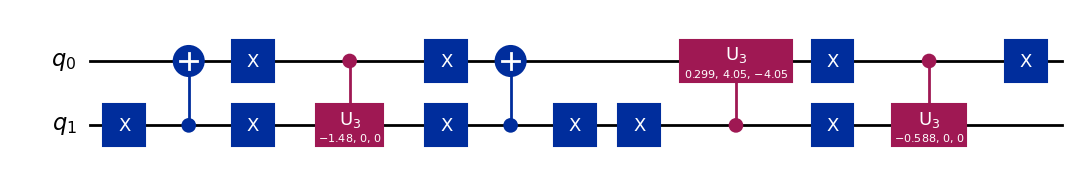

In [349]:
qc=QuantumCircuit(2)
qc.append(PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [0, 1])
qc.decompose().draw('mpl')

In [350]:
def U1_omega_Omega(t):
    A = -1 * omega * t
    B_val = -1 * Omega * t
    gate = QuantumCircuit(2)
    gate.rz(A, 0)
    gate.rz(B_val, 1)
    return gate.to_gate(label='U1_omega_Omega')


In [351]:
def nunu_interaction(qc, q, alpha):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha, d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha, b)
    qc.rz(alpha, c)
    qc.rz(alpha, d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha, c)
    qc.cx(a, c)
    qc.rz(-alpha, c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

def phase_gate(qc, q, p):
    phase = np.exp(1j * p) * np.eye(2)
    qc.unitary(phase, q, label='phase')

def nunu_interaction_p(qc, q, alpha, p=[np.pi/2, -np.pi/2, np.pi/4], basis='ecr'):
    """
    Currently only supports either "cx" or "ecr" for basis
    """
    a, b, c, d = q

    if basis == 'cx':
    # implement the original scheme in cx gates
        qc.cx(a, c)
        qc.cx(b, d)
        qc.ry(np.pi/4, a)
        qc.ry(np.pi/4, b)
        qc.cx(c, a)
        qc.cx(d, b)
        qc.ry(-np.pi/4, a)
        qc.ry(-np.pi/4, b)
        qc.rz(-alpha, c)
        qc.rz(-alpha + p[0], d)
        qc.cx(a, c)
        qc.cx(b, d)
        qc.cx(a, b)
        qc.rz(-2 * alpha + p[0], b)
        qc.rz(alpha, c)
        qc.rz(alpha + p[1], d)
        qc.cx(a, b)
        qc.cx(b, c)
        qc.rz(alpha + p[1], c)
        qc.cx(a, c)
        qc.rz(-alpha + p[0], c)
        qc.cx(a, d)
        qc.cx(b, c)
        qc.rz(alpha, d)
        qc.cx(b, d)
        qc.rz(-alpha, d)
        qc.cx(a, d)
        qc.ry(np.pi/4, a)
        qc.ry(np.pi/4, b)
        qc.cx(d, b)
        qc.cx(c, a)
        qc.ry(-np.pi/4, a)
        qc.ry(-np.pi/4, b)
        qc.cx(b, d)
        qc.cx(a, c)
    elif basis == 'ecr':
        with open('../circuits/nunu_interact_ecr.qpy', 'rb') as f:
            c = qk.qpy.load(f)
            c = c[0]
        c = c.assign_parameters({c.parameters[0]:alpha})
        c = c.to_gate(label='nunu_interact_ecr')
        qc.append(c, q)

# def nunu_interaction_p(qc, q, alpha, p=[np.pi/2, -np.pi/2, np.pi/4], basis='ecr'):
#     """
#     Currently only supports either "cx" or "ecr" for basis
#     """
#     with open('../circuits/nunu_interact_swap.qpy', 'rb') as f:
#         c = qk.qpy.load(f)
#         c = c[0]
#     c = c.assign_parameters({c.parameters[0]:alpha})
#     c = c.to_gate(label='nunu_interact_swap')
#     qc.append(c, q)

def nunu_interaction_pisom(qc, q, alpha, p=[np.pi/2, -np.pi/2, np.pi/4]):
        a, b, c, d = 0, 1, 2, 3
        gate = QuantumCircuit(4)
        gate.cx(a, c)
        gate.cx(b, d)
        gate.ry(np.pi/4, a)
        gate.ry(np.pi/4, b)
        gate.cx(c, a)
        gate.cx(d, b)
        gate.ry(-np.pi/4, a)
        gate.ry(-np.pi/4, b)
        gate.rz(-alpha, c)
        gate.rz(-alpha + p[0], d)
        gate.cx(a, c)
        gate.cx(b, d)
        gate.cx(a, b)
        gate.rz(-2 * alpha + p[0], b)
        gate.rz(alpha, c)
        gate.rz(alpha + p[1], d)
        gate.cx(a, b)
        gate.cx(b, c)
        gate.rz(alpha + p[1], c)
        gate.cx(a, c)
        gate.rz(-alpha + p[0], c)
        gate.cx(a, d)
        gate.cx(b, c)
        gate.rz(alpha, d)
        gate.cx(b, d)
        gate.rz(-alpha, d)
        gate.cx(a, d)
        gate.ry(np.pi/4, a)
        gate.ry(np.pi/4, b)
        gate.cx(d, b)
        gate.cx(c, a)
        gate.ry(-np.pi/4, a)
        gate.ry(-np.pi/4, b)
        gate.cx(b, d)
        gate.cx(a, c)

        op = Operator(gate.to_gate())
        isom = qk.circuit.library.Isometry(op, 0, 0)
        a, b, c, d = q
        qc.append(isom, [a, b, c, d])

def two_qubit_swap(qc, q1, q2):
    # begin 0.0 0.1 1.0 1.1
    qc.swap(q1[1], q2[0]) # 0.0 1.0 0.1 1.1
    qc.swap(q2[0], q2[1]) # 0.0 1.0 1.1 0.1
    qc.swap(q1[0], q1[1]) # 1.0 0.0 1.1 0.1
    qc.swap(q1[1], q2[0]) # 1.0 1.1 0.0 0.1

    # qc.swap(q1[0], q2[0])
    # qc.swap(q1[1], q2[1]) 

In [352]:
# def apply_nunu_interaction(qc, pair_indices, alpha_list):
#     for i, j, alpha_ij in alpha_list:
#         q = [2*i, 2*i+1, 2*j, 2*j+1]
#         nunu_interaction(qc, q, alpha_ij)

def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, basis='cx'):
    for i, j in pair_indices:
        # print(order)
        # print(base_pattern)
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E) * dt
        # print("Interacting pairs: ", i, j)
        # print("Interacting qubits: ", q)
        # print("Interacting order: ", order)
        # print("Interacting base pattern: ", base_pattern)
        if explicit_swap_flag:
            nunu_interaction(qc, q, alpha_ij)
            two_qubit_swap(qc, [2*i, 2*i+1], [2*j, 2*j+1])
        else:
            if not ISOM_FLAG:
                print("Using paper decomposition")
                nunu_interaction_p(qc, q, alpha_ij, basis=basis)
            else:
                print("Using isometry")
                nunu_interaction_pisom(qc, q, alpha_ij)
        order = swap_order_i_j(order, i, j)
        base_pattern = swap_base_pattern_i_j(base_pattern, i, j)
        # print("New order: ", order)
        # print("New base pattern: ", base_pattern)
    return order, base_pattern

def swap_order_i_j(order, i, j):
    order[i], order[j] = order[j], order[i]
    return order

def swap_base_pattern_i_j(base_pattern, i, j):
    base_pattern[i], base_pattern[j] = base_pattern[j], base_pattern[i]
    return base_pattern


In [353]:
def interact_pair(qc, i, j, order, base_pattern, dt):
    alpha_ij = J_ij(order[i], order[j], E) * dt
    q = [2*i, 2*i+1, 2*j, 2*j+1]
    if explicit_swap_flag:
        nunu_interaction(qc, q, alpha_ij)
        two_qubit_swap(qc, [2*i, 2*i+1], [2*j, 2*j+1])
    else:
        if not ISOM_FLAG:
            nunu_interaction_p(qc, q, alpha_ij)
        else:
            nunu_interaction_pisom(qc, q, alpha_ij)
    order = swap_order_i_j(order, i, j)
    base_pattern = swap_base_pattern_i_j(base_pattern, i, j)
    return order, base_pattern

def interact_pair_no_swap(qc, i, j, order, base_pattern, dt):
    alpha_ij = J_ij(order[i], order[j], E) * dt
    q = [2*i, 2*i+1, 2*j, 2*j+1]
    if not ISOM_FLAG:
        nunu_interaction(qc, q, alpha_ij)
    else:
        nunu_interaction_pisom(qc, q, alpha_ij)
    return order, base_pattern

def full_tree_interact(qc, pair_indices, order, base_pattern, dt):
    """
    Implements the most depth efficient and fully symmetric interaction
    @assumes that N is 2^n
    """
    if np.log2(N) % 1 != 0:
        raise ValueError("full tree interaction only works for N=2^n")
    halfN = int(N / 2) # always int when N is even
    halfNm1 = int(halfN - 1)
    for r in range(halfN): # this the the number of rounds

        # we first interact adjacent pairs

        for i in range(halfN):
            order, base_pattern = interact_pair(qc, 2*i, 2*i+1, order, base_pattern, dt)
        
        # then we interact the newly contacted pairs

        if r != halfNm1:
            for i in range(halfNm1):
                order, base_pattern = interact_pair(qc, 2*i+1, 2*i+2, order, base_pattern, dt)
        else:
            for i in range(halfNm1):
                # If this is the last operation in the last round, we do not swap
                # this is for potentially applying Second-Order Suzuki-Trotter
                # this allows direct contact between same operation gates in the forward and reverse trotter
                order, base_pattern = interact_pair_no_swap(qc, 2*i+1, 2*i+2, order, base_pattern, dt)

    return order, base_pattern

def full_tree_interact_reversed(qc, pair_indices, order, base_pattern, dt):
    """
    This is the reversed version of the full tree interaction, for applying 2nd order Suzuki-Trotter
    @assumes that N is 2^n
    """
    if np.log2(N) % 1 != 0:
        raise ValueError("full tree interaction only works for N=2^n")
    halfN = int(N / 2) # always int when N is even
    halfNm1 = int(halfN - 1)
    for r in range(halfN): # this the the number of rounds

        # we first interact middle pairs

        for i in range(halfNm1):
            order, base_pattern = interact_pair(qc, 2*i+1, 2*i+2, order, base_pattern, dt)
        
        # then we interact all adjacent pairs
        if r != halfNm1:
            for i in range(halfN):
                order, base_pattern = interact_pair(qc, 2*i, 2*i+1, order, base_pattern, dt)
        else:
            for i in range(halfN):
                order, base_pattern = interact_pair_no_swap(qc, 2*i, 2*i+1, order, base_pattern, dt)
                
    return order, base_pattern


In [354]:
def init_ordering():
    # pair_indices = [(i, j) for i in range(N) for j in range(i+1, N)]
    # every interaction we push the current first element to end of qubits
    # sort of like what happens in bubble sort
    pair_indices = []
    for j in range(N):
        nmj = N - j - 1
        for i in range(nmj):
            pair_indices.append((i, i+1))
    # print(pair_indices)
    # this should totally reverse the order of the qubits
    # i.e 1234 -> 4321
    order = [i for i in range(N)] # initial order (physical mapping to neutrinos)

    # Target initial state pattern: 00 01 00 10 00 01 00 10 ...
        # Target initial state pattern based on same logic as initial state
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e
        # Reverse the *pairs*, not individual bits
    return pair_indices, order, base_pattern

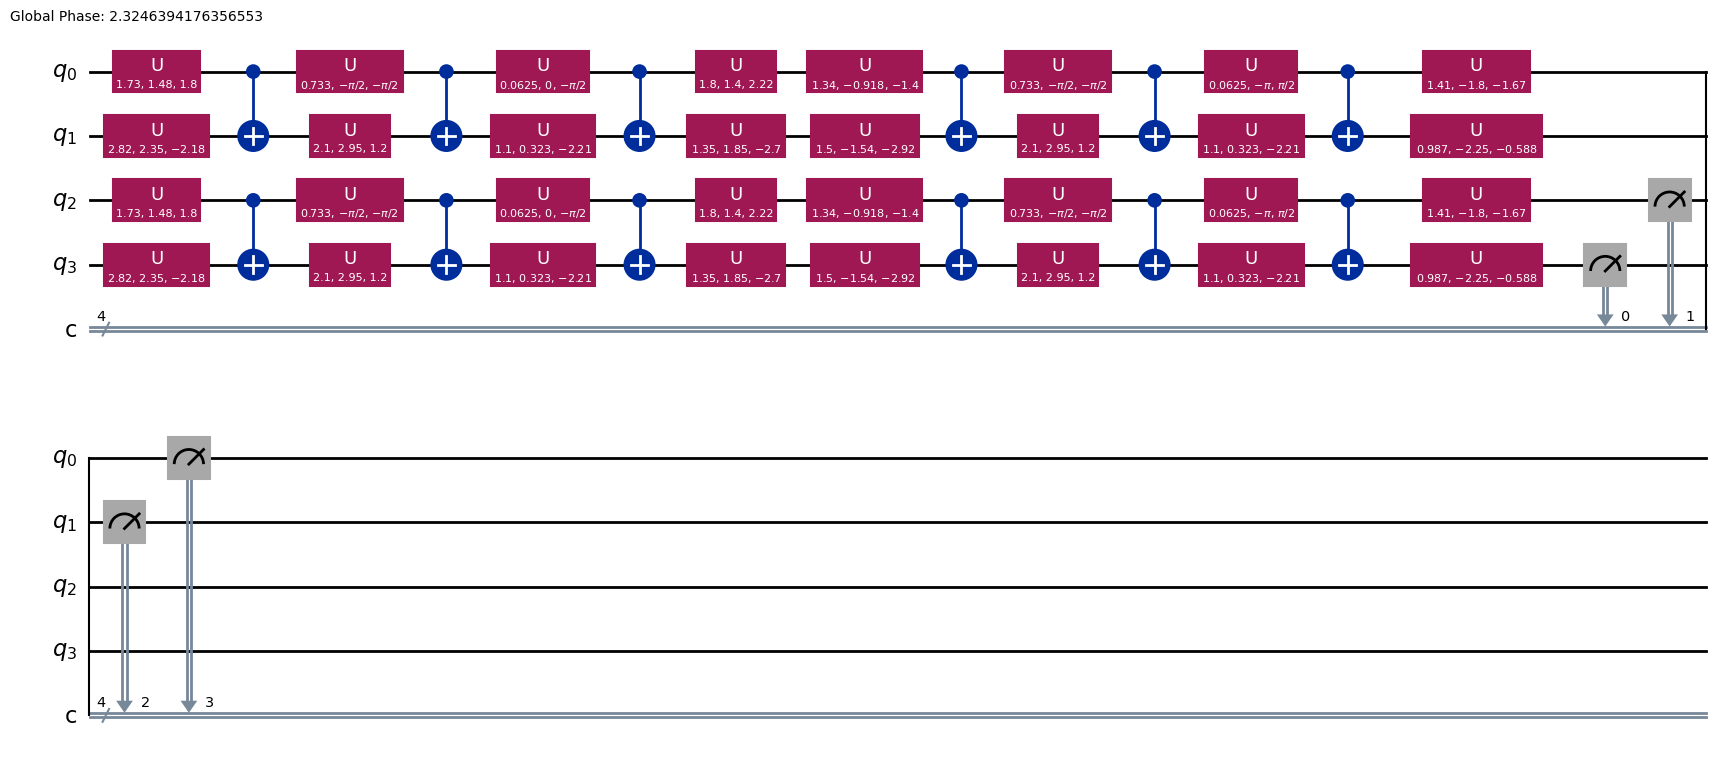

In [355]:
qc = QuantumCircuit(4, 4)

# Apply U†_PMNS
Udag = Operator(U_PMNS_4x4.conj().T)
qc.unitary(Udag, [0, 1], label="U†_PMNS")
qc.unitary(Udag, [2, 3], label="U†_PMNS")

# Apply U_PMNS
U = Operator(U_PMNS_4x4)
qc.unitary(U, [0, 1], label="U_PMNS")
qc.unitary(U, [2, 3], label="U_PMNS")

# Measurement
# if order[-1] > order[0]:
qc.measure(range(4), reversed(range(4)))
qc.decompose(reps=1).draw('mpl')

  0%|          | 0/17 [00:00<?, ?it/s]

# of 2q gates after first PMNS:  4
# of 2q gates after second PMNS:  8


circuit saved to circuit.txt
TPC has 0 2q gates
IC has 0 2q gates


  6%|▌         | 1/17 [00:03<00:52,  3.30s/it]

Target state: 00010010
Measurement counts: {'00100011': 0, '10000011': 0, '00001011': 0, '01111010': 0, '01010111': 0, '11011010': 0, '00011011': 0, '01010000': 2, '01010110': 5, '00100000': 1, '00000011': 0, '10000010': 28, '01000010': 34, '00010110': 352, '00000110': 17, '00110011': 0, '01010011': 0, '10010010': 648, '01100010': 3, '00110010': 0, '10010111': 0, '00010010': 57205, '00011110': 0, '00100010': 112, '00010000': 276, '00011010': 405, '00010001': 4, '10110011': 0, '00010011': 0, '01010010': 618, '00110000': 0, '10010011': 0, '00011000': 2, '10011010': 4, '00111010': 0, '00001010': 22, '00010100': 1, '10010110': 2, '10110010': 0, '11010010': 0, '01011010': 5, '00000000': 12, '10010000': 7, '00000010': 2977, '01110010': 0, '00110110': 0, '10100010': 4}
Original probabilities:  0.9116915819335097
Original probabilities2:  0.936676025390625
Estimated error rate: 0.1298828125
Probabilities:  1.047780224354561
Probabilities2:  1.0764941077441077
# of 2q gates after first PMNS:  4

...

Target state: 10010000
Measurement counts: {'11111011': 0, '00111110': 0, '01000111': 0, '01111010': 0, '01111110': 0, '11011101': 0, '00110111': 0, '01111100': 0, '11111101': 0, '11100111': 0, '01001011': 0, '01111011': 0, '10111100': 0, '10011010': 128, '01001111': 0, '00001101': 0, '01101111': 0, '10111010': 0, '11000011': 0, '11001111': 0, '00111101': 0, '00011100': 0, '01011100': 0, '00110110': 0, '00110100': 0, '10000111': 0, '11000101': 0, '10111011': 0, '10011011': 0, '11001010': 0, '00110101': 0, '10101101': 0, '01111000': 0, '11011110': 0, '10101100': 0, '01101101': 0, '00001000': 134, '10101111': 0, '00111010': 0, '01011110': 0, '01111111': 0, '01110101': 0, '10110000': 0, '01010101': 164, '11111010': 0, '11011010': 0, '11010101': 0, '00011111': 0, '11001011': 0, '01111001': 0, '10111111': 0, '11101000': 0, '10100101': 248, '10110010': 0, '00111011': 0, '11111111': 0, '01001010': 93, '10110110': 0, '10100110': 201, '11101101': 0, '11010111': 0, '01000101': 102, '00101010': 4

 94%|█████████▍| 16/17 [01:13<00:04,  4.64s/it]

Target state: 10010000
Measurement counts: {'01001111': 0, '01101111': 0, '11001101': 0, '01111011': 0, '10101001': 150, '01001011': 0, '11001100': 0, '11010111': 0, '00111101': 0, '11011101': 0, '11001011': 0, '00111010': 0, '10101110': 0, '11101011': 0, '01011100': 0, '10111111': 0, '11101000': 0, '01000101': 140, '10111010': 0, '11001111': 0, '11111010': 0, '01011011': 0, '00000100': 262, '00001101': 0, '11000100': 0, '01111110': 0, '01110111': 0, '00001100': 0, '11011010': 0, '11011001': 0, '11110011': 0, '10101101': 0, '00110101': 0, '00000011': 0, '11000101': 0, '00111100': 0, '01101010': 193, '10110001': 0, '00110111': 0, '11000011': 0, '11011110': 0, '11001010': 0, '10100010': 576, '10001011': 0, '11111110': 0, '00011110': 0, '11111001': 0, '10000110': 161, '11001110': 0, '01010110': 147, '10111011': 0, '10011011': 0, '01011110': 0, '11010110': 0, '01000100': 293, '01111100': 0, '10010111': 0, '10011100': 0, '11101100': 0, '10100110': 152, '01111010': 0, '01010101': 175, '11000

100%|██████████| 17/17 [01:18<00:00,  4.60s/it]

Target state: 10010000
Measurement counts: {'01111111': 0, '11111101': 0, '11111010': 0, '01111011': 0, '01110101': 0, '01011011': 0, '11101010': 0, '11111011': 0, '00111110': 0, '11100111': 0, '11010111': 0, '01111010': 0, '00110111': 0, '01111001': 0, '10001111': 0, '00000101': 109, '01110111': 0, '00001100': 0, '01100110': 118, '01011110': 0, '10001110': 0, '11101110': 0, '11001110': 0, '01010110': 143, '01000111': 0, '11001101': 0, '10110001': 0, '10010111': 0, '11111001': 0, '10000110': 141, '11001011': 0, '00111010': 0, '11101100': 0, '00000011': 0, '11101011': 0, '10101110': 0, '01101111': 0, '11011110': 0, '11001010': 0, '11000101': 0, '11100100': 0, '11011010': 0, '00111000': 0, '01000101': 127, '10001011': 0, '01011001': 119, '01100100': 300, '11110011': 0, '01001011': 0, '11011100': 0, '01111100': 0, '11000100': 0, '00001101': 0, '01110011': 0, '11001111': 0, '11010101': 0, '00011111': 0, '11011001': 0, '10101001': 102, '10011100': 0, '11110101': 0, '11100010': 0, '01011111'

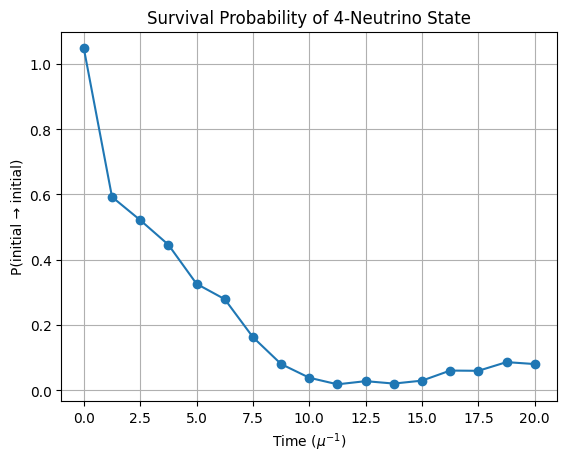

In [356]:

# ----------------------- Trotter step setup -----------------------
# Time loop setup for N neutrinos

if trotter_scheme == 0:
    # fix step size
    dt = 0.5 / mu
    T_max = 20 / mu
    steps = int(T_max / dt) + 1
    times = np.linspace(0, T_max, steps)

else:
    # fix number of steps
    dt = 1.25 # placeholder
    T_max = 20 / mu
    steps = 17
    internal_steps = 1
    times = np.linspace(0, T_max, steps)


# ----------------------- Simulation setup -----------------------
# Defines auxcillary functions and variables
probabilities = [] # initial state survival probability
probabilities2 = [] # nu_0 survival probability
error = []
error_stat = []
if PAULI_TWIRLING_FLAG:
    shots = pt_rands * pt_shots
else:
    shots = 65536

def phs_correct(counts):
    """
    Correct the counts by using phs in https://arxiv.org/pdf/2407.13914
    This removed unphysical '11' states
    """
    if PHS_FLAG:
        for key in counts.keys():
            for digi in range(N):
                if key[2*digi] == '1' and key[2*digi+1] == '1':
                    counts[key] = 0
                    break
    
        norm = 0
        for key in counts.keys():
            norm += counts[key]
    return norm

def get_target_state(base_pattern):
    target_state = ''.join((base_pattern))
    # if order[-1] > order[0]:
        # we are in original order
    target_state = target_state.replace('M', '01')
    target_state = target_state.replace('T', '10')
    target_state = target_state.replace('E', '00')
    return target_state

def calculate_nu_survival(probabilities, n, shots, order, counts, initial='00'):
    c = 0
    nu_0_loc = np.where(np.asarray(order) == n)[0][0]
    for key in counts.keys():
        if key[2*nu_0_loc] == initial[0] and key[2*nu_0_loc+1] == initial[1]: # initial nu_e state
            if not PHS_FLAG:
                c += counts[key]
            else:
                for digi in range(N):
                    if key[2*digi] == '1' and key[2*digi+1] == '1':
                        break
                else:
                    c += counts[key]
    if not M3FLAG:
        prob = c / shots
        # already a probability after M3
    else:
        prob = c
    probabilities.append(prob)

def run(pqc):
    if simulator_flag:
        jr = JobResult(service = simulator, verbose = True)
    else:
        jr = JobResult(service = sampler, verbose = True)
    
    jr.run(pqc, {'shots': shots})

def run_and_get_counts(pqc):
    counts = None
    job = None
    # Execute circuit
    job = simulator.run([pqc], shots=shots) if simulator_flag else sampler.run([pqc], shots=shots)
    job_result = job.result()

    # Extract counts based on result format
    counts = job_result.get_counts() if simulator_flag else job_result[0].data.c.get_counts()

    if M3FLAG:
        counts = mit.apply_correction(counts, initial_layout).nearest_probability_distribution()
    
    return counts

def append_probabilities(counts, target_state, prob1, prob2):
    # here we count all non-physical states
    norm = phs_correct(counts)

    if PHS_FLAG:
        prob = counts.get(target_state, 0) / norm
    else:
        prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    prob1.append(prob)

    calculate_nu_survival(prob2, 0, shots, order, counts, '00')

    if PHS_FLAG:
        error = np.sqrt(prob * (1 - prob) / norm)
    else:
        error = np.sqrt(prob * (1 - prob) / shots)
    
    return error

def produce_transpile_args(opt_lvl = 3):
    transpile_args = {
        'optimization_level': opt_lvl
    }

    if simulator_flag:
        # For simulator backend
        transpile_args['target'] = target
        
        if config is not None and hasattr(config, 'supported_instructions'):
            transpile_args['basis_gates'] = config.supported_instructions
        
    else:
        # For real quantum hardware
        transpile_args['initial_layout'] = initial_layout
        
        if config is not None and hasattr(config, 'supported_instructions'):
            transpile_args['basis_gates'] = config.supported_instructions
    
    # transpile_args['layout_method'] = 'sabre'
    transpile_args['approximation_degree'] = APPROXIMATION_DEGREE
        
    return transpile_args

# ----------------------- simulation loop -----------------------

for it, t in enumerate(tqdm(times)):
    qc = QuantumCircuit(2 * N, 2 * N)

    pair_indices, order, base_pattern = init_ordering()

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    if PMNS_TYPE == 0:
        Udag = Operator(U_PMNS_4x4.conj().T)
        for i in range(N):
            qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")
    elif PMNS_TYPE == 1:
        for i in range(N):
            qc.append(PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [2*i, 2*i+1])

    print("# of 2q gates after first PMNS: ", count_2q(qc))
    
    # Trotterization

    if trotter_scheme == 1 and t != 0:
        dt = t / internal_steps

    Trotter = int(t / dt)
    for trott in range(Trotter):
        """
        Since H_nu and H_nunu terms commute, we can trotter them separately 
        """
        # pair_alphas = [(i, j, J_ij(i, j, E) * dt) for i, j in pair_indices]
        for i in range(N):
            qc.append(U1_omega_Omega(dt), [2*i, 2*i+1])
    
    for _ in range(Trotter):
        print("Trotter step: ")
        if not MIN_DEPTH_INTERACT:
            order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt)
        else:
            if not SUZUKI_TROTTER_FLAG:
                order, base_pattern = full_tree_interact(qc, pair_indices, order, base_pattern, dt)
            else:
                if (not DYNAMIC_SUZUKI_FLAG) or dt > 5/mu:
                    order, base_pattern = full_tree_interact(qc, pair_indices, order, base_pattern, dt/2)
                    order, base_pattern = full_tree_interact_reversed(qc, pair_indices, order, base_pattern, dt/2)
                else:
                    order, base_pattern = full_tree_interact(qc, pair_indices, order, base_pattern, dt)
        print("# of 2q gates after Trotter step: ", count_2q(qc))
    # Apply U_PMNS
    if PMNS_TYPE == 0:
        U = Operator(U_PMNS_4x4)
        for i in range(N):
            qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")
    elif PMNS_TYPE == 1:
        for i in range(N):
            qc.append(PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [2*i, 2*i+1])
    
    print("# of 2q gates after second PMNS: ", count_2q(qc))
            
    # Measurement
    # if order[-1] > order[0]:
    qc.measure(range(2 * N), reversed((range(2 * N))))
    # if t == times[1]:
    #     fig = qc.draw('mpl')
    #     fig.savefig("IBM_{0}_neutrinos_circuit.png".format(N))
    # else:
    #     qc.measure(reversed(range(2 * N)), reversed((range(2 * N))))
    pqc = None

    # Prepare common transpiler arguments

    transpile_args = produce_transpile_args()
    
    pqc = transpile(qc, backend, **transpile_args)

    with open("circuit.txt", "w") as f:
        f.write(pqc.draw('text').single_string())
        print("circuit saved to circuit.txt")


    print("TPC has {0} 2q gates".format(count_2q(pqc)))


    if DR_FLAG:
        dr = DR(pqc)
        print("IC has {0} 2q gates".format(count_2q(dr.get_identity_circuit())))
        if simulator_flag:
            dr.estimate_error_rate(service = simulator, transpile_options = transpile_args, plan=PLAN)
        else:
            dr.estimate_error_rate(service = sampler, transpile_options = transpile_args, plan=PLAN)
    if PLAN == 1:
        counts = run(pqc)
        continue
    counts = run_and_get_counts(pqc)

    target_state = get_target_state(base_pattern)
    
    print("Target state:", target_state)

    er_stat = append_probabilities(counts, target_state, probabilities, probabilities2)
    error_stat.append(er_stat)

    if DR_FLAG:
        print("Original probabilities: ", probabilities[-1])
        print("Original probabilities2: ", probabilities2[-1])
        probabilities[-1] = dr.renormalize(probabilities[-1])
        probabilities2[-1] = dr.renormalize(probabilities2[-1])
        print("Estimated error rate:", dr.get_rate_estimate())
        error_stat[-1] = dr.renormalize(er_stat)
        error.append(dr.get_rate_estimate())
        print("Probabilities: ", probabilities[-1])
        print("Probabilities2: ", probabilities2[-1])
    
    if ZERO_NOISE_EXTRAP_FLAG:
        """
        In this case, proceed with Zero Noise Extrapolation
        This goes in the steps:

        1. Rescale the circuit with more noise
        2. Run the circuit and store temporary counts
        3. Repeat 1 and 2 for all noise factors
        4. Apply extrapolation to get final counts at the end
        """
        

        zne_prob = [probabilities[-1]]
        zne_prob2 = [probabilities2[-1]]

        for i, lambd in enumerate(zne_noise_factors):
            if lambd == 1:
                # this is just the original circuit we just ran
                continue

            sqc = generate_noise_scaled_circuit(qc, lambd)

            transpile_args = produce_transpile_args(0)

            sqc = transpile(sqc, backend, **transpile_args)

            counts = run_and_get_counts(sqc)

            nprob1, nprob2 = [], []
            append_probabilities(counts, target_state, zne_prob, zne_prob2)
        # @TODO: we are currently assuming same shots across all noise levels (same weights)

        fprob, fprob2 = [], []

        # try:

        print("Attempting to fit: ", zne_prob)
        zne_prob_val = extrapolate_to_zero(zne_prob, zne_noise_factors, zne_extrapolator)
        print("Attempting to fit: ", zne_prob2)
        zne_prob_val2 = extrapolate_to_zero(zne_prob2, zne_noise_factors, zne_extrapolator)
        print("Extrapolated values: ", zne_prob_val, zne_prob_val2)

        # Here if fit was sucessful, use ZNE extrapolated values
        probabilities[-1] = zne_prob_val
        probabilities2[-1] = zne_prob_val2

        # except Exception as e:
        #     print("Unable to extrapolate, error:", e)
        #     print("Extrapolation failed, using original probabilities")

# Plot
if PLAN == 2 or PLAN == 3:
    if SAVEFIG_FLAG:
        np.save(save_prob_name+"_prob", probabilities)
        np.save(save_prob_name+"_e", times * mu)
        np.save(save_prob_name+"_error", error_stat)
        np.save(save_prob_name+"_error_rate", error)

    plt.plot(times * mu, probabilities, marker='o')
    plt.xlabel(r"Time ($\mu^{-1}$)")
    plt.ylabel("P(initial → initial)")
    plt.title("Survival Probability of {0}-Neutrino State".format(N))
    plt.grid(True)
    if SAVEFIG_FLAG:
        plt.savefig(save_postfix+".png")
        # plt.savefig("IBM_{0}_neutrinos".format(N) + save_postfix + ".pdf")

    plt.show()

# plt.plot(times * mu, probabilities2, marker='o')
# plt.xlabel(r"Time ($\mu^{-1}$)")
# plt.ylabel("nu_0 (initial → initial)")
# plt.title("Survival Probability of nu_0 (nu_e)".format(N))
# plt.grid(True)
# if SAVEFIG_FLAG:
#     plt.savefig("IBM_{0}_neutrinos_nu0".format(N) + save_postfix + ".png")
    # plt.savefig("IBM_{0}_neutrinos_nu0".format(N) + save_postfix + ".pdf")

plt.show()


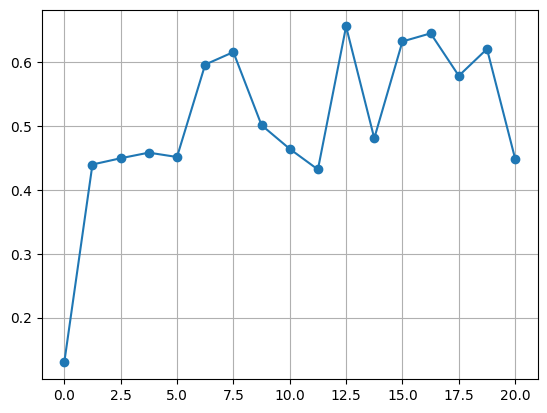

In [357]:
plt.plot(times * mu, error, marker='o')
plt.grid('on')

In [358]:
for j in service.jobs():
    print(j)
    try:
        j.cancel()
    except Exception as e:
        pass

NameError: name 'service' is not defined